In [1]:
import zipfile
import os

DATA_PATH = "/kaggle/input/datasets/codingveenitkumar/ail7031-cv-final-sub"
WORK_DIR = "/kaggle/working"

for file in os.listdir(DATA_PATH):

    if file.endswith(".zip"):

        zip_path = os.path.join(DATA_PATH, file)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(WORK_DIR)

print("Files extracted successfully")

Files extracted successfully


# PART 1 — Training Analysis (Plots)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
import os

print(os.listdir("/kaggle/input/datasets/codingveenitkumar/ail7031-cv-final-sub"))

['folds_0_outputs (1)', 'folds_1_outputs (1)', 'folds_2_outputs (1)', 'folds_3_outputs (1)']


In [4]:
import numpy as np
import os

# ------------------------------------------------
# DATASET PATH
# ------------------------------------------------
DATA_PATH = "/kaggle/input/datasets/codingveenitkumar/ail7031-cv-final-sub"

# ------------------------------------------------
# FOLDS
# ------------------------------------------------
folds = [0, 1, 2, 3]

# ------------------------------------------------
# STORAGE
# ------------------------------------------------
train_acc = []
val_acc = []
asym = []
recall = []
roc = []

# ------------------------------------------------
# LOAD METRICS
# ------------------------------------------------
for f in folds:

    folder = f"folds_{f}_outputs (1)"
    base = os.path.join(DATA_PATH, folder)

    train_acc.append(np.load(os.path.join(base, f"train_acc_fold_{f}.npy")))
    val_acc.append(np.load(os.path.join(base, f"val_acc_fold_{f}.npy")))
    asym.append(np.load(os.path.join(base, f"asym_fold_{f}.npy")))
    recall.append(np.load(os.path.join(base, f"recall_fold_{f}.npy")))
    roc.append(np.load(os.path.join(base, f"roc_fold_{f}.npy")))

print("Metrics loaded successfully")

for i in range(4):
    print(f"Fold {i} epochs:", len(train_acc[i]))

Metrics loaded successfully
Fold 0 epochs: 13
Fold 1 epochs: 13
Fold 2 epochs: 13
Fold 3 epochs: 13


**3. Train vs Validation Accuracy**

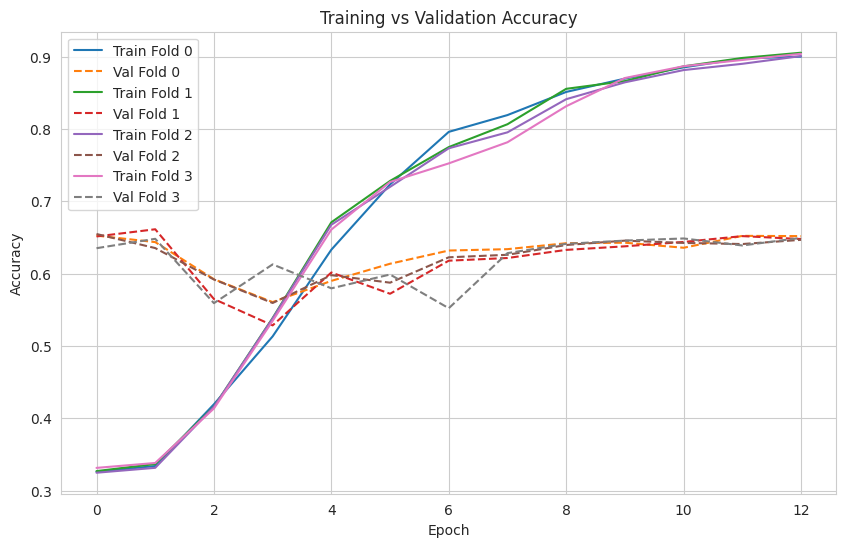

In [5]:
plt.figure(figsize=(10,6))

for i in range(4):
    
    plt.plot(train_acc[i], label=f"Train Fold {i}")
    plt.plot(val_acc[i], linestyle="--", label=f"Val Fold {i}")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**4. Asymmetric Score curves**

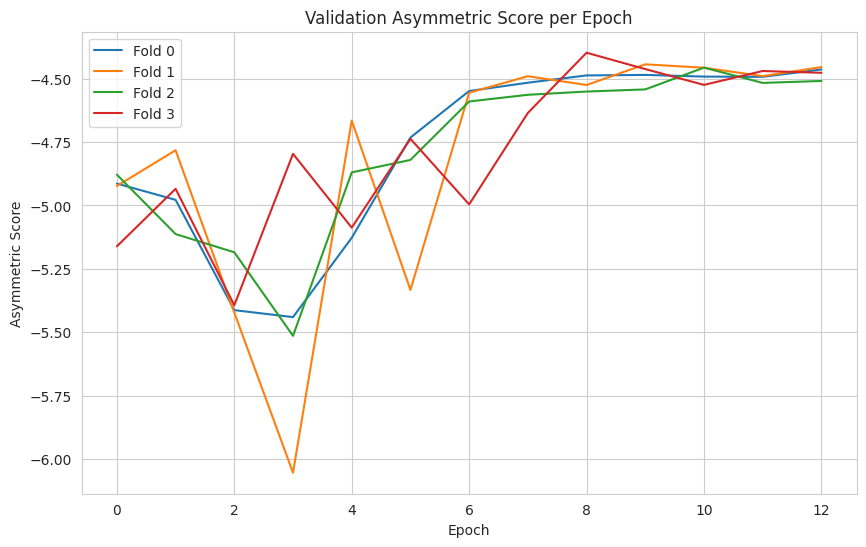

In [6]:
plt.figure(figsize=(10,6))

for i in range(4):
    
    plt.plot(asym[i], label=f"Fold {i}")

plt.title("Validation Asymmetric Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Asymmetric Score")
plt.legend()
plt.show()

**5. Recall curves**

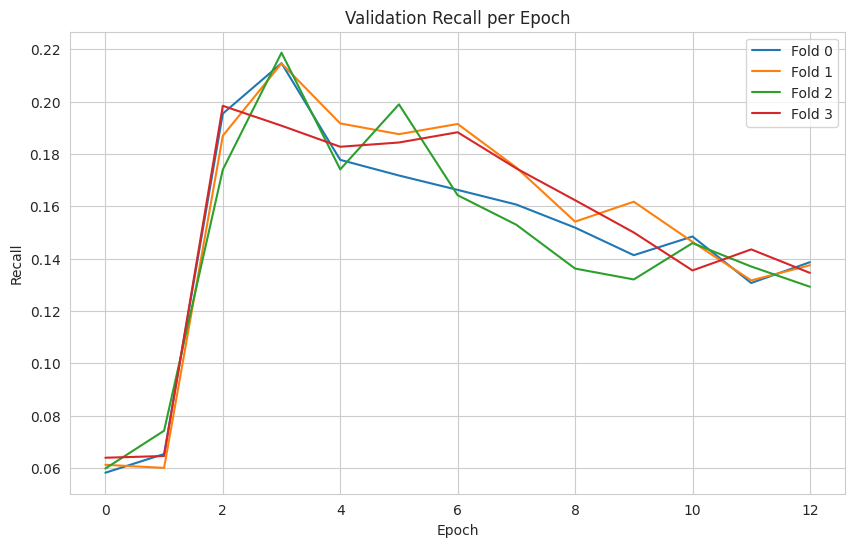

In [7]:
plt.figure(figsize=(10,6))

for i in range(4):
    
    plt.plot(recall[i], label=f"Fold {i}")

plt.title("Validation Recall per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.show()

**6. ROC AUC curves**

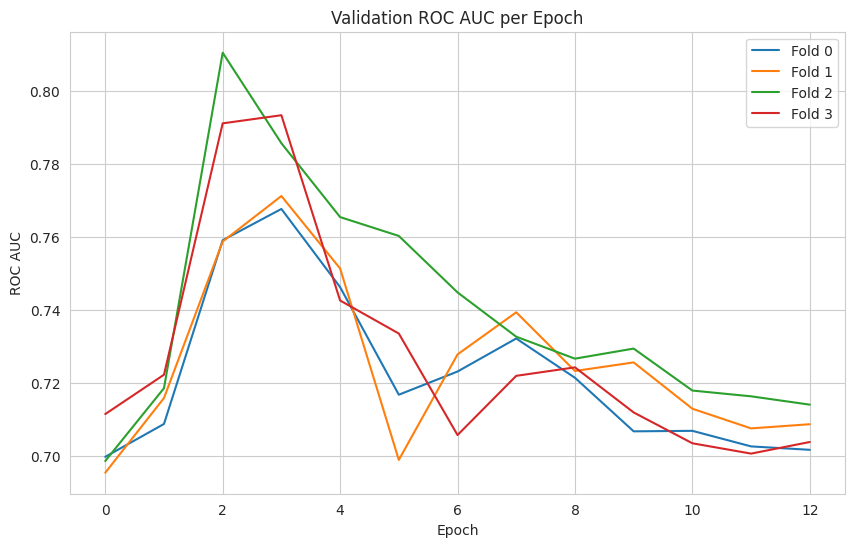

In [8]:
plt.figure(figsize=(10,6))

for i in range(4):
    
    plt.plot(roc[i], label=f"Fold {i}")

plt.title("Validation ROC AUC per Epoch")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.legend()
plt.show()

**7. Fold comparison (final metrics)**

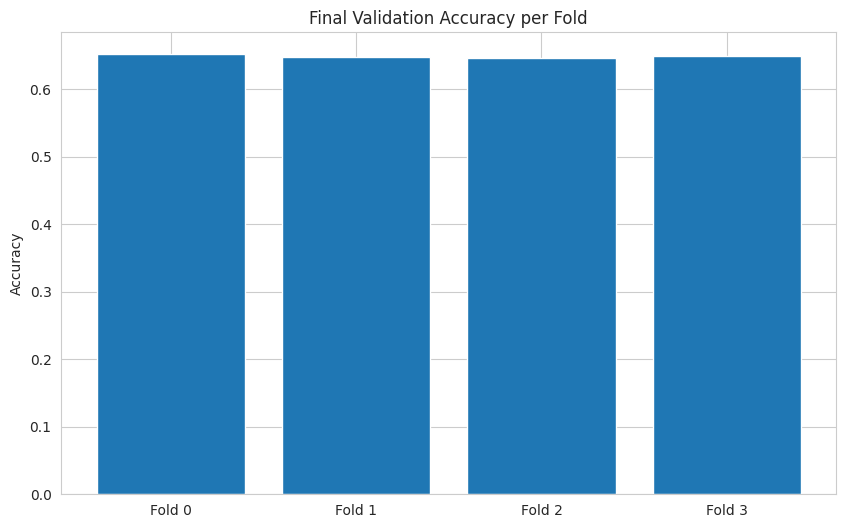

In [9]:
final_acc = [v[-1] for v in val_acc]
final_asym = [v[-1] for v in asym]
final_recall = [v[-1] for v in recall]
final_roc = [v[-1] for v in roc]

x = np.arange(4)

plt.figure(figsize=(10,6))
plt.bar(x, final_acc)
plt.xticks(x, [f"Fold {i}" for i in x])
plt.title("Final Validation Accuracy per Fold")
plt.ylabel("Accuracy")
plt.show()

**8. Final Asymmetric Score per fold**

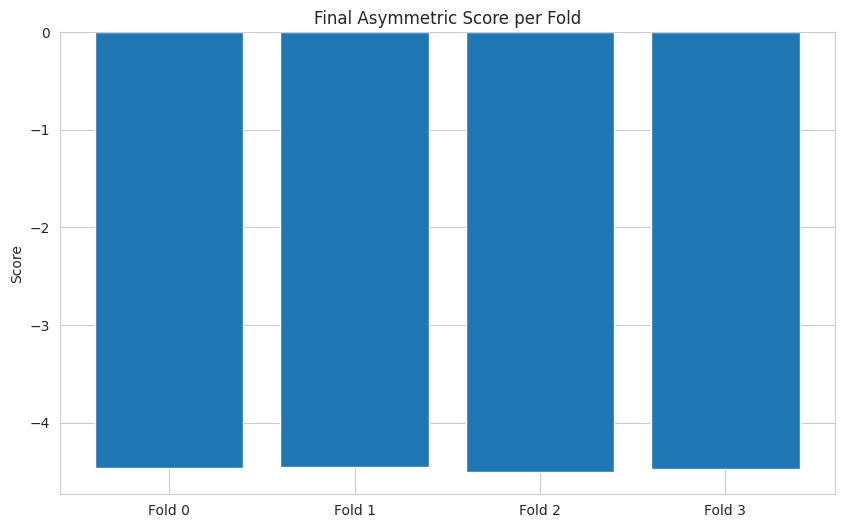

In [10]:
plt.figure(figsize=(10,6))

plt.bar(x, final_asym)

plt.xticks(x, [f"Fold {i}" for i in x])

plt.title("Final Asymmetric Score per Fold")

plt.ylabel("Score")

plt.show()

**9. Mean CV accuracy curve**

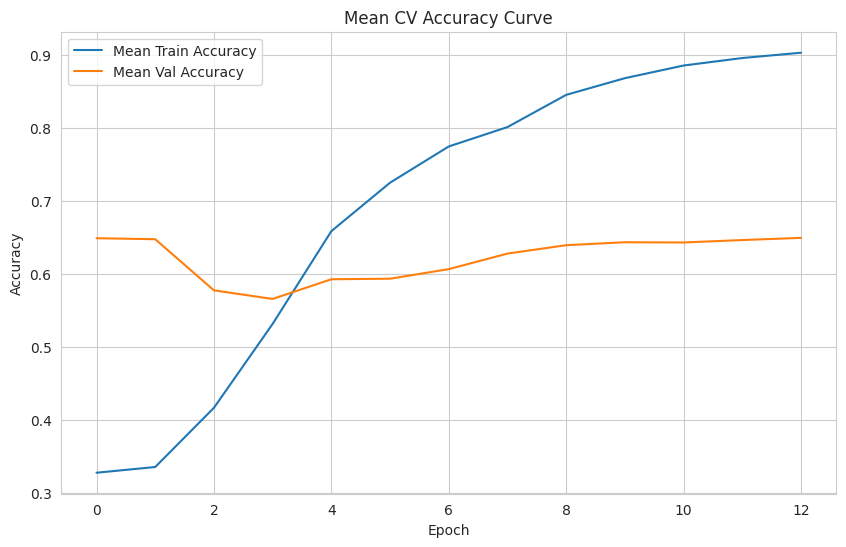

In [11]:
train_acc_stack = np.stack(train_acc)
val_acc_stack = np.stack(val_acc)

mean_train = train_acc_stack.mean(axis=0)
mean_val = val_acc_stack.mean(axis=0)

plt.figure(figsize=(10,6))

plt.plot(mean_train, label="Mean Train Accuracy")
plt.plot(mean_val, label="Mean Val Accuracy")

plt.title("Mean CV Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

**10. Mean Asymmetric Score curve**

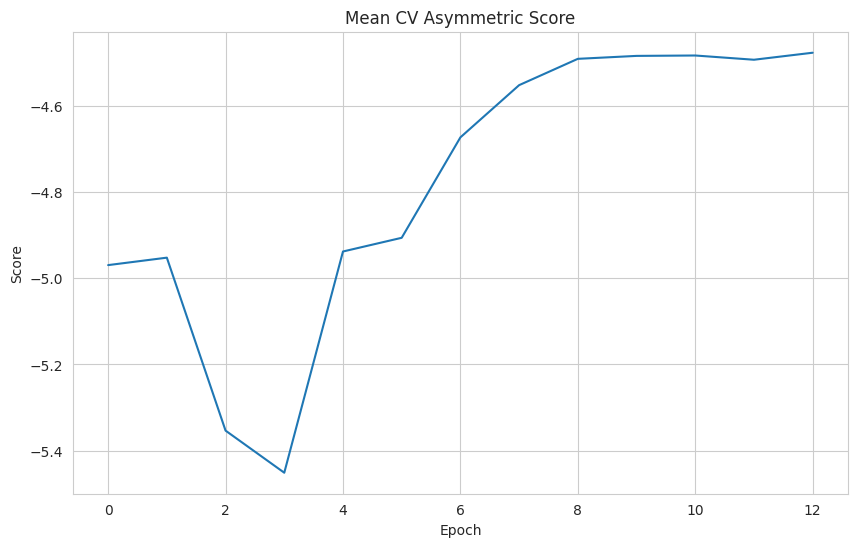

In [12]:
asym_stack = np.stack(asym)

mean_asym = asym_stack.mean(axis=0)

plt.figure(figsize=(10,6))

plt.plot(mean_asym)

plt.title("Mean CV Asymmetric Score")
plt.xlabel("Epoch")
plt.ylabel("Score")

plt.show()

**11. Train-Validation gap (overfitting indicator)**

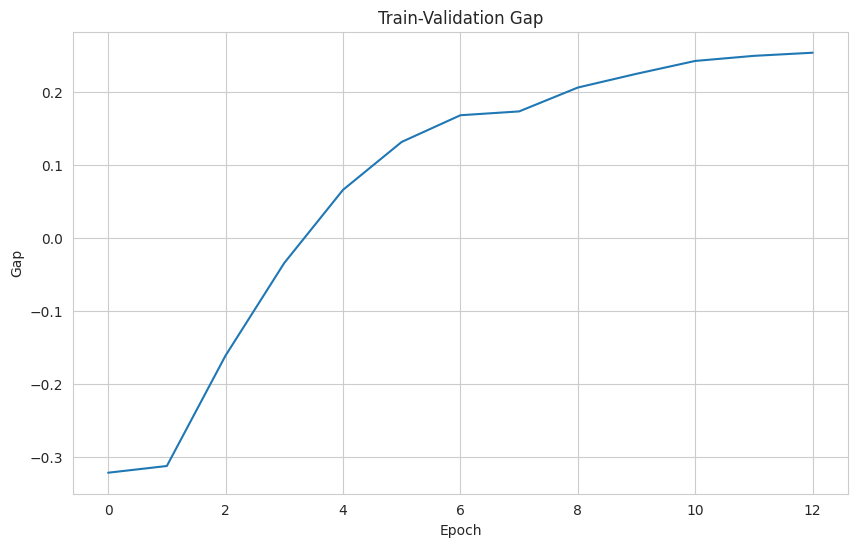

In [13]:
gap = mean_train - mean_val

plt.figure(figsize=(10,6))

plt.plot(gap)

plt.title("Train-Validation Gap")
plt.xlabel("Epoch")
plt.ylabel("Gap")

plt.show()

**12. Epoch variance across folds**

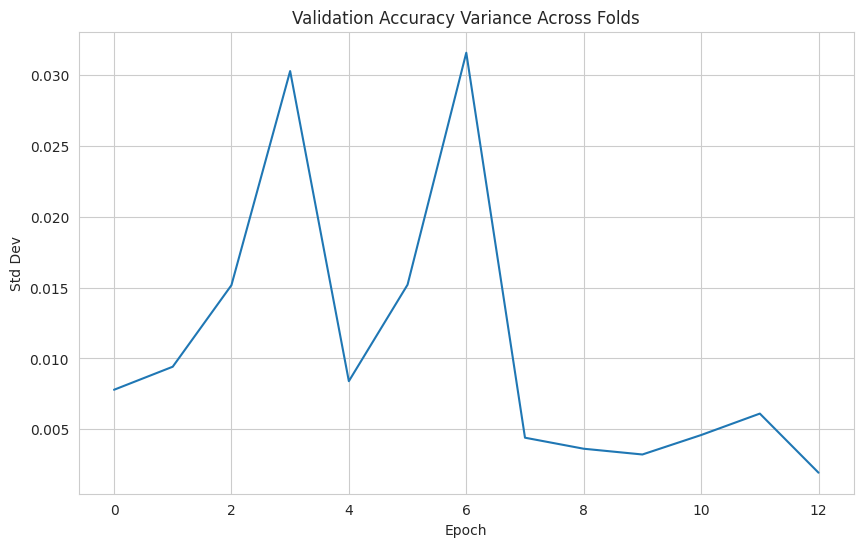

In [14]:
std_acc = val_acc_stack.std(axis=0)

plt.figure(figsize=(10,6))

plt.plot(std_acc)

plt.title("Validation Accuracy Variance Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Std Dev")

plt.show()

**13. Heatmap of metrics across folds**

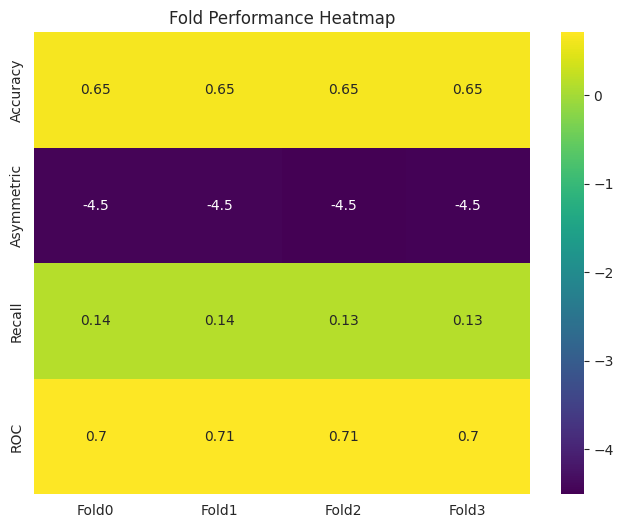

In [15]:
data = np.array([
    final_acc,
    final_asym,
    final_recall,
    final_roc
])

plt.figure(figsize=(8,6))

sns.heatmap(
    data,
    annot=True,
    cmap="viridis",
    xticklabels=[f"Fold{i}" for i in range(4)],
    yticklabels=["Accuracy","Asymmetric","Recall","ROC"]
)

plt.title("Fold Performance Heatmap")

plt.show()

**15. Metric distribution**

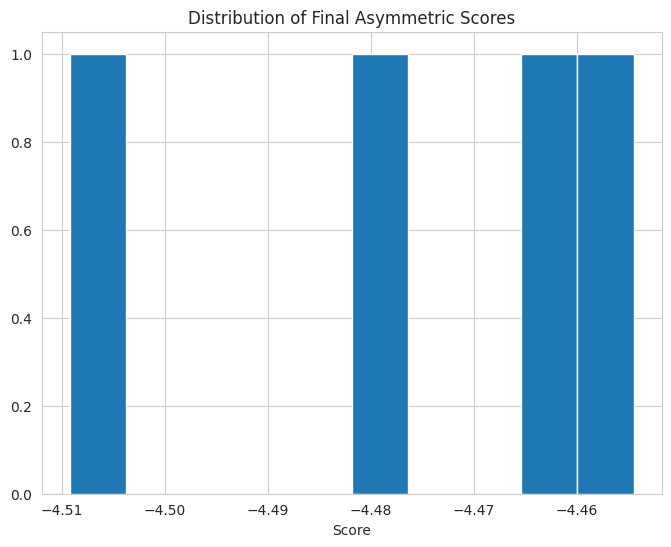

In [16]:
plt.figure(figsize=(8,6))

plt.hist(final_asym, bins=10)

plt.title("Distribution of Final Asymmetric Scores")

plt.xlabel("Score")

plt.show()

**16. Load validation predictions from folds**

In [17]:
val_probs_all = []
val_targets_all = []

for f in folds:

    folder = f"folds_{f}_outputs (1)"
    base = os.path.join(DATA_PATH, folder)

    probs = np.load(os.path.join(base, f"val_probs_fold_{f}.npy"))
    targets = np.load(os.path.join(base, f"val_targets_fold_{f}.npy"))

    val_probs_all.append(probs)
    val_targets_all.append(targets)

val_probs = np.concatenate(val_probs_all)
val_targets = np.concatenate(val_targets_all)

print("Validation probs shape:", val_probs.shape)
print("Validation targets shape:", val_targets.shape)

Validation probs shape: (68058, 20)
Validation targets shape: (68058,)


**17. ROC curves for all diseases**

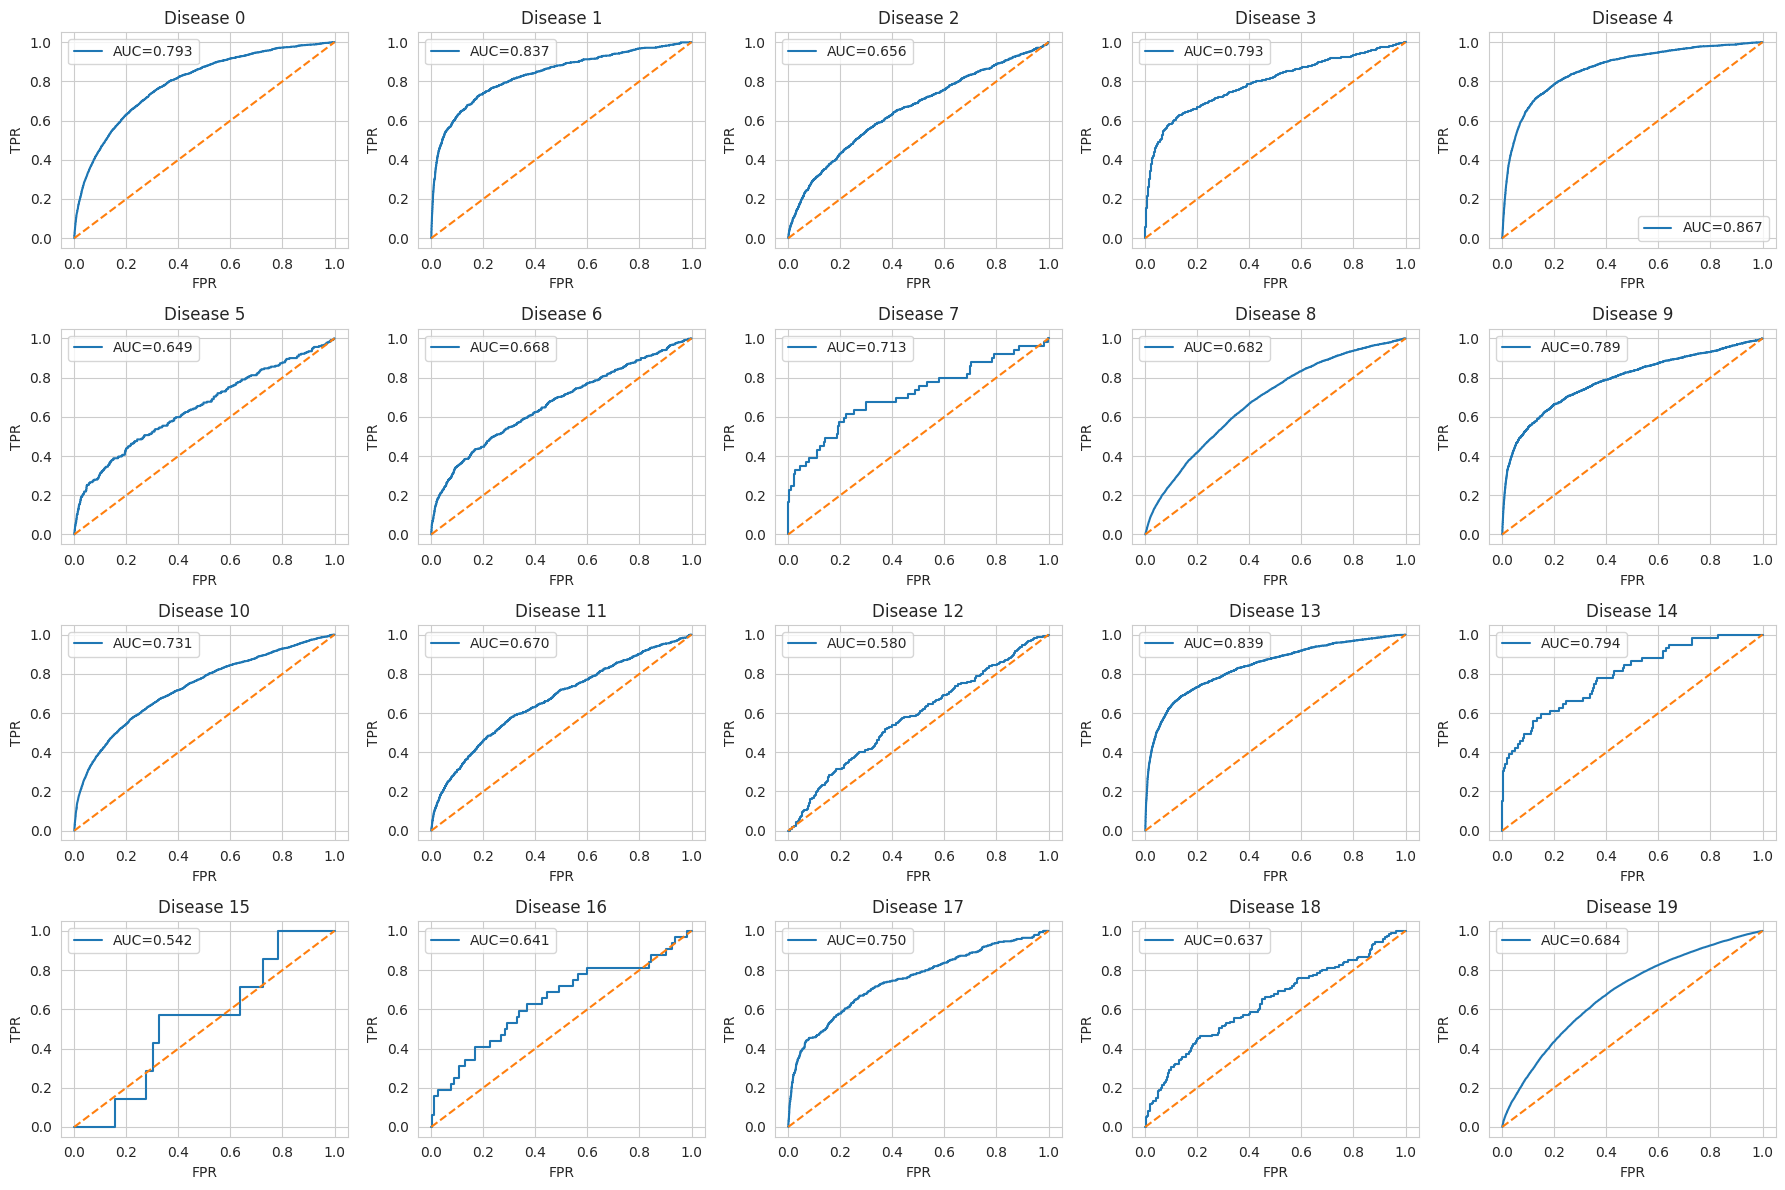

In [18]:
from sklearn.metrics import roc_curve, auc

NUM_CLASSES = 20

fig, axes = plt.subplots(4,5,figsize=(18,12))
axes = axes.flatten()

for c in range(NUM_CLASSES):

    y_true = (val_targets == c).astype(int)
    y_score = val_probs[:,c]

    fpr, tpr, _ = roc_curve(y_true,y_score)
    roc_auc = auc(fpr,tpr)

    axes[c].plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
    axes[c].plot([0,1],[0,1],'--')

    axes[c].set_title(f"Disease {c}")
    axes[c].set_xlabel("FPR")
    axes[c].set_ylabel("TPR")
    axes[c].legend()

plt.tight_layout()
plt.show()

**18. Per-disease ROC AUC**

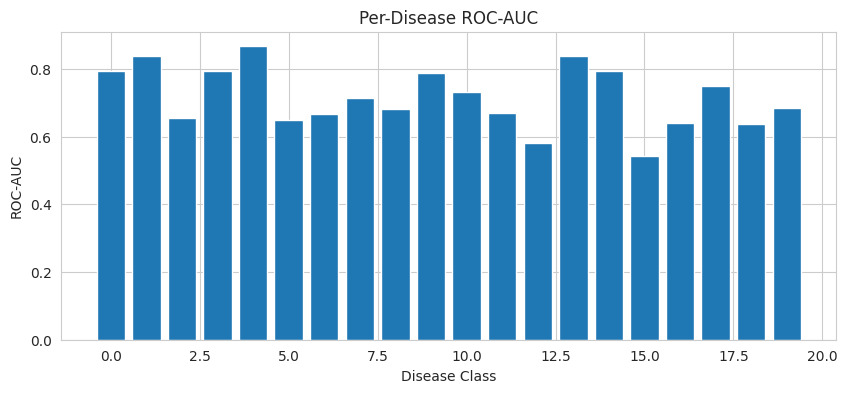

In [19]:
auc_scores = []

for c in range(NUM_CLASSES):

    y_true = (val_targets == c).astype(int)
    y_score = val_probs[:,c]

    fpr, tpr, _ = roc_curve(y_true,y_score)
    roc_auc = auc(fpr,tpr)

    auc_scores.append(roc_auc)

plt.figure(figsize=(10,4))

plt.bar(range(NUM_CLASSES),auc_scores)

plt.xlabel("Disease Class")
plt.ylabel("ROC-AUC")

plt.title("Per-Disease ROC-AUC")

plt.show()

**19. Best and worst detected diseases**

In [20]:
worst_class = np.argmin(auc_scores)
best_class = np.argmax(auc_scores)

print("Best detected disease:",best_class,"AUC:",auc_scores[best_class])
print("Worst detected disease:",worst_class,"AUC:",auc_scores[worst_class])

Best detected disease: 4 AUC: 0.8665159080555145
Worst detected disease: 15 AUC: 0.5424964889778044


**20. Confusion matrix**

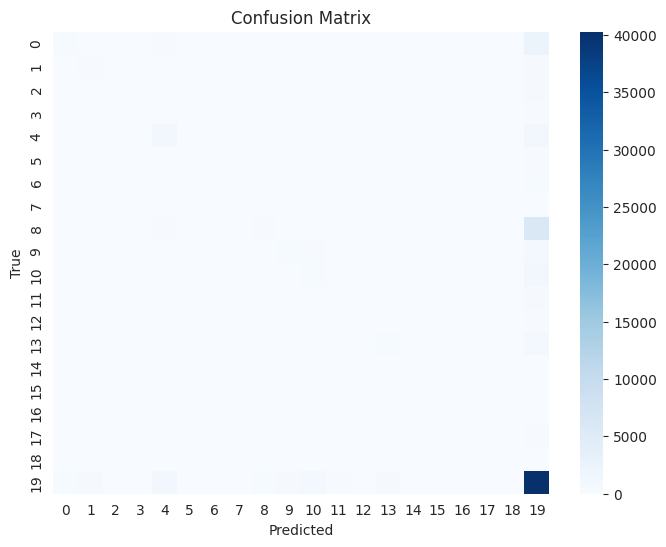

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_preds = np.argmax(val_probs,axis=1)

cm = confusion_matrix(val_targets,val_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm,cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

**21. Per-class recall**

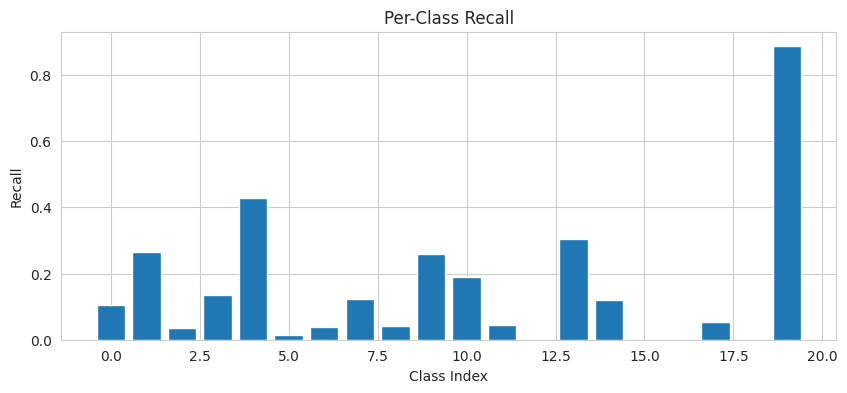

In [22]:
from sklearn.metrics import recall_score

per_class_recall = recall_score(
    val_targets,
    val_preds,
    average=None
)

plt.figure(figsize=(10,4))

plt.bar(range(NUM_CLASSES),per_class_recall)

plt.xlabel("Class Index")
plt.ylabel("Recall")

plt.title("Per-Class Recall")

plt.show()

**22. Threshold analysis for class 0**

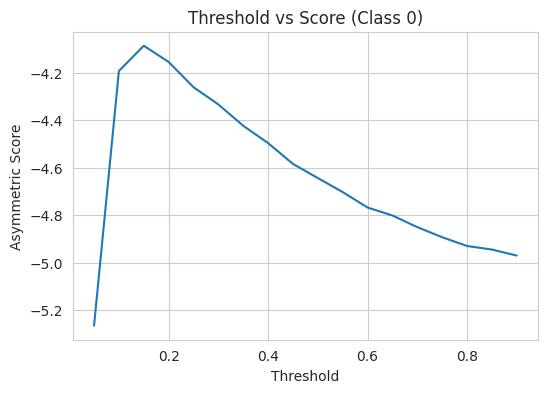

In [23]:
thresholds = np.linspace(0.05,0.9,18)
scores = []

targets_bin = (val_targets==0).astype(int)

for t in thresholds:

    preds = (val_probs[:,0] > t).astype(int)

    tp = np.sum((preds==1)&(targets_bin==1))
    fp = np.sum((preds==1)&(targets_bin==0))
    fn = np.sum((preds==0)&(targets_bin==1))

    nc = np.sum(targets_bin)

    score = (tp - fp - 5*fn)/nc

    scores.append(score)

plt.figure(figsize=(6,4))

plt.plot(thresholds,scores)

plt.xlabel("Threshold")
plt.ylabel("Asymmetric Score")
plt.title("Threshold vs Score (Class 0)")

plt.show()

**23. Top Confused Disease Pairs**

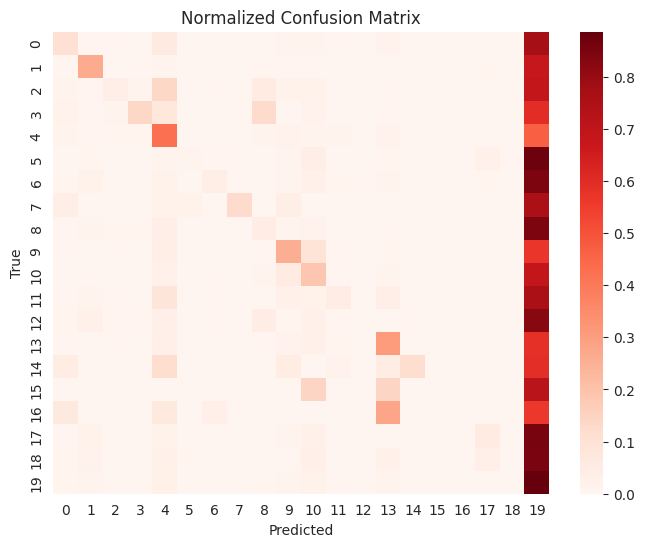

In [24]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_norm,
    cmap="Reds"
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

**24. ROC-AUC Distribution**

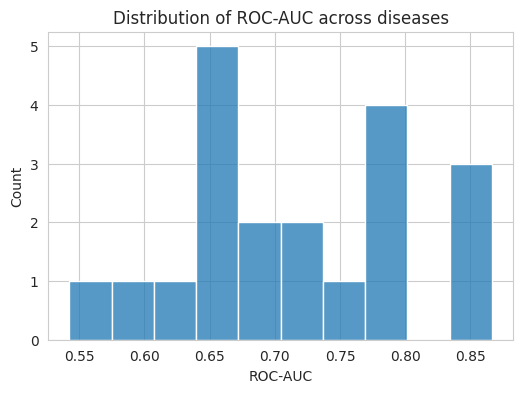

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(auc_scores, bins=10)

plt.xlabel("ROC-AUC")
plt.title("Distribution of ROC-AUC across diseases")

plt.show()

**25. Disease Difficulty Ranking**

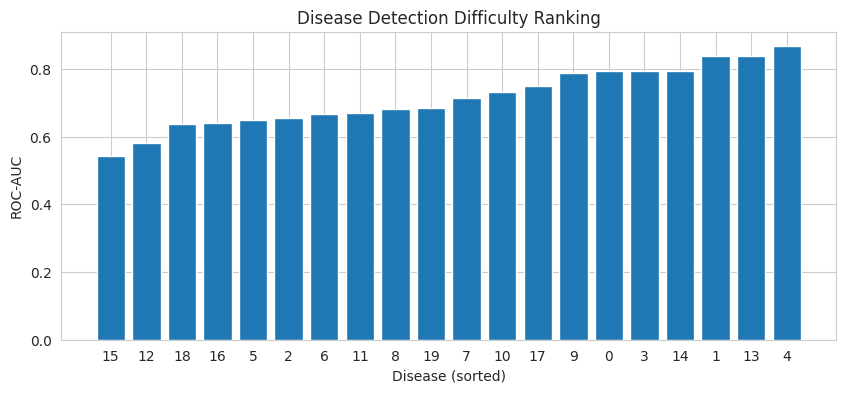

In [26]:
sorted_idx = np.argsort(auc_scores)

plt.figure(figsize=(10,4))

plt.bar(range(NUM_CLASSES), np.array(auc_scores)[sorted_idx])

plt.xticks(range(NUM_CLASSES), sorted_idx)

plt.xlabel("Disease (sorted)")
plt.ylabel("ROC-AUC")

plt.title("Disease Detection Difficulty Ranking")

plt.show()

**23. Prepare cross-validation predictions**

In [27]:
print("Preparing validation data for threshold optimization...")

print("Validation probabilities shape:", val_probs.shape)
print("Validation targets shape:", val_targets.shape)

Preparing validation data for threshold optimization...
Validation probabilities shape: (68058, 20)
Validation targets shape: (68058,)


**24. Asymmetric score metric**

In [28]:
def asymmetric_score(y_true, y_pred):

    scores = []

    for c in range(NUM_CLASSES):

        tp = np.sum((y_true==c) & (y_pred==c))
        fp = np.sum((y_true!=c) & (y_pred==c))
        fn = np.sum((y_true==c) & (y_pred!=c))

        nc = np.sum(y_true==c)

        if nc == 0:
            continue

        score = (tp - fp - 5*fn) / nc

        scores.append(score)

    return np.mean(scores)

**25. Baseline argmax predictions**

In [29]:
baseline_preds = np.argmax(val_probs, axis=1)

baseline_score = asymmetric_score(
    val_targets,
    baseline_preds
)

print("Baseline Asymmetric Score:", baseline_score)

Baseline Asymmetric Score: -4.440670356562839


**26. Threshold search**

In [30]:
def find_best_thresholds(probs, targets):

    thresholds = []

    for c in range(NUM_CLASSES):

        best_t = 0.5
        best_score = -1e9

        for t in np.linspace(0.05,0.9,18):

            pred = (probs[:,c] > t).astype(int)
            true = (targets==c).astype(int)

            tp = np.sum((pred==1)&(true==1))
            fp = np.sum((pred==1)&(true==0))
            fn = np.sum((pred==0)&(true==1))

            nc = np.sum(true)

            if nc == 0:
                continue

            score = (tp - fp - 5*fn)/nc

            if score > best_score:

                best_score = score
                best_t = t

        thresholds.append(best_t)

    return np.array(thresholds)

**27. Find optimal thresholds**

In [31]:
print("Searching optimal thresholds...")

best_thresholds = find_best_thresholds(
    val_probs,
    val_targets
)

print("Best thresholds per class:")
print(best_thresholds)

Searching optimal thresholds...
Best thresholds per class:
[0.15 0.35 0.65 0.4  0.2  0.9  0.55 0.3  0.15 0.2  0.4  0.9  0.85 0.2
 0.55 0.1  0.65 0.9  0.85 0.05]


**28. Threshold based predictions**

In [32]:
threshold_preds = []

for i in range(len(val_probs)):

    probs = val_probs[i]

    detected = np.where(probs > best_thresholds)[0]

    if len(detected) == 0:
        pred = np.argmax(probs)
    else:
        pred = detected[np.argmax(probs[detected])]

    threshold_preds.append(pred)

threshold_preds = np.array(threshold_preds)

**29. Score after threshold tuning**

In [33]:
threshold_score = asymmetric_score(
    val_targets,
    threshold_preds
)

print("Baseline score:", baseline_score)
print("Threshold tuned score:", threshold_score)

Baseline score: -4.440670356562839
Threshold tuned score: -4.38122116238519


**30. Improvement comparison**

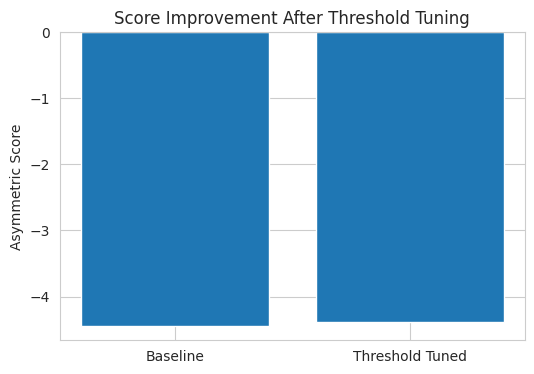

In [34]:
plt.figure(figsize=(6,4))

scores = [baseline_score, threshold_score]

plt.bar(["Baseline","Threshold Tuned"], scores)

plt.ylabel("Asymmetric Score")

plt.title("Score Improvement After Threshold Tuning")

plt.show()

**31. Optimal thresholds per disease**

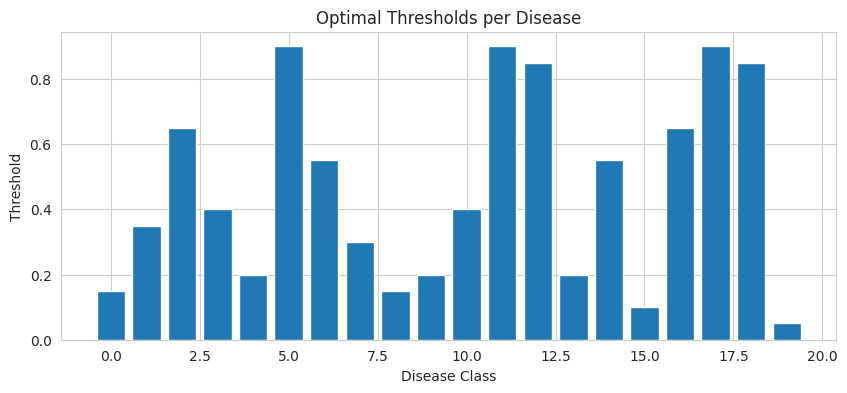

In [35]:
plt.figure(figsize=(10,4))

plt.bar(range(NUM_CLASSES), best_thresholds)

plt.xlabel("Disease Class")
plt.ylabel("Threshold")

plt.title("Optimal Thresholds per Disease")

plt.show()

**32. Threshold distribution**

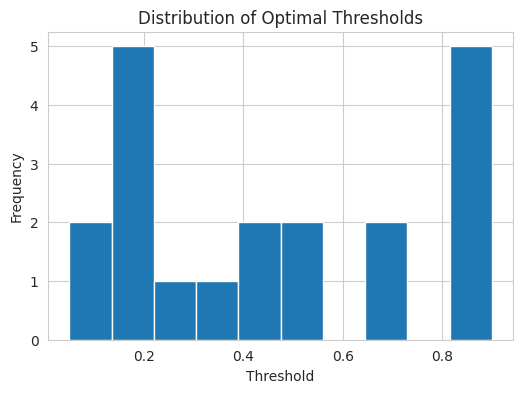

In [36]:
plt.figure(figsize=(6,4))

plt.hist(best_thresholds, bins=10)

plt.xlabel("Threshold")
plt.ylabel("Frequency")

plt.title("Distribution of Optimal Thresholds")

plt.show()

**33. Save threshold tuning outputs**

In [37]:
OUTPUT_DIR = "/kaggle/working/cv_analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save thresholds
np.save(
    os.path.join(OUTPUT_DIR, "best_thresholds.npy"),
    best_thresholds
)

# Save CV predictions
np.save(
    os.path.join(OUTPUT_DIR, "cv_val_probs.npy"),
    val_probs
)

np.save(
    os.path.join(OUTPUT_DIR, "cv_val_targets.npy"),
    val_targets
)

# Save tuned predictions
np.save(
    os.path.join(OUTPUT_DIR, "cv_threshold_preds.npy"),
    threshold_preds
)

# Save scores
scores = {
    "baseline_score": baseline_score,
    "threshold_score": threshold_score
}

import json

with open(os.path.join(OUTPUT_DIR, "scores.json"), "w") as f:
    json.dump(scores, f)

print("CV analysis outputs saved.")

import shutil

shutil.make_archive(
    "/kaggle/working/cv_analysis_outputs",
    'zip',
    OUTPUT_DIR
)

print("Zip file created for download.")

CV analysis outputs saved.
Zip file created for download.


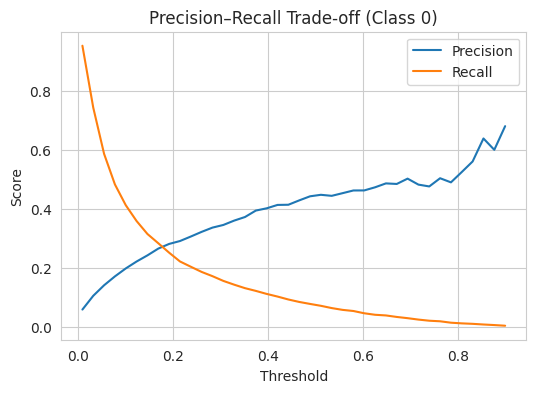

In [38]:
from sklearn.metrics import precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# choose one class to demonstrate (e.g. class 0)
CLASS_ID = 0

thresholds = np.linspace(0.01,0.9,40)

precision_list = []
recall_list = []

y_true = (val_targets == CLASS_ID).astype(int)

for t in thresholds:

    preds = (val_probs[:, CLASS_ID] > t).astype(int)

    precision = precision_score(y_true, preds)
    recall = recall_score(y_true, preds)

    precision_list.append(precision)
    recall_list.append(recall)

plt.figure(figsize=(6,4))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision–Recall Trade-off (Class {CLASS_ID})")

plt.legend()
plt.show()

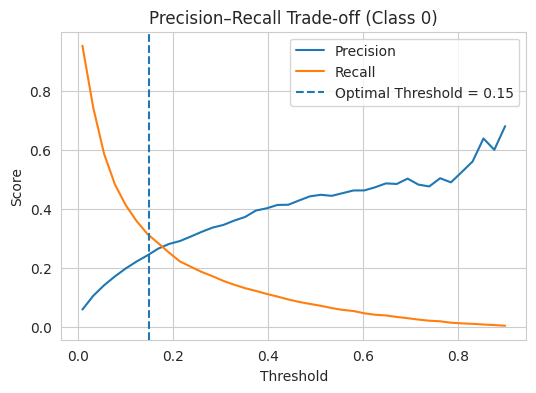

In [39]:
best_t = best_thresholds[0]

plt.figure(figsize=(6,4))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")

plt.axvline(best_t, linestyle="--", label=f"Optimal Threshold = {best_t:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off (Class 0)")
plt.legend()

plt.show()

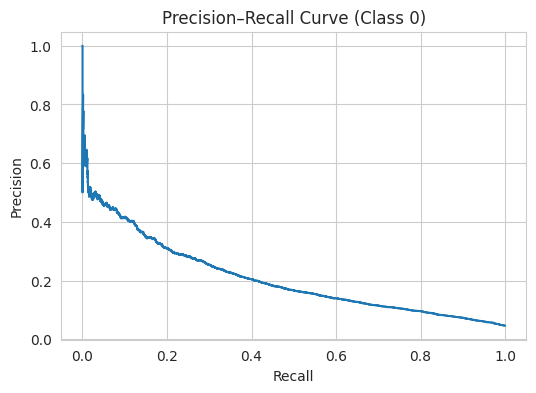

In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, val_probs[:,0])

plt.figure(figsize=(6,4))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Class 0)")

plt.show()

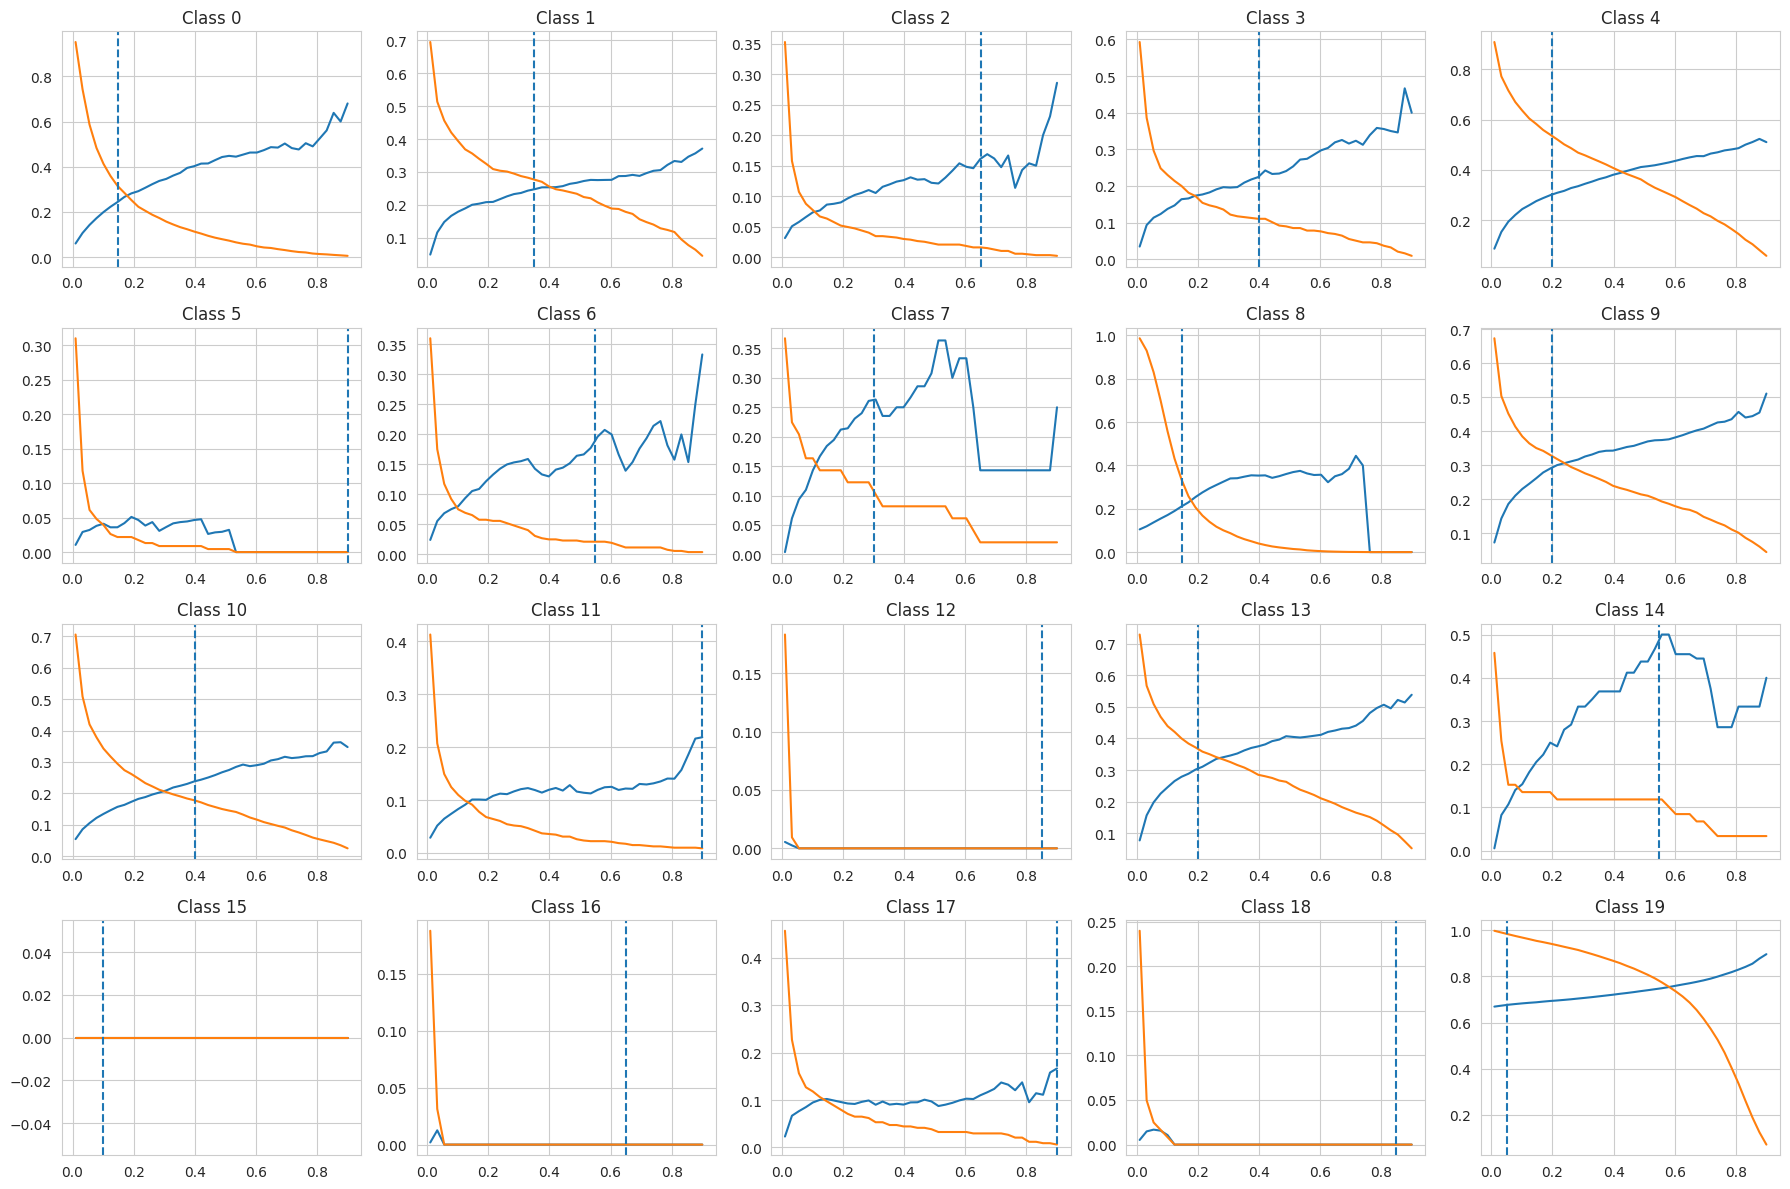

In [41]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.01,0.9,40)

fig, axes = plt.subplots(4,5, figsize=(18,12))
axes = axes.flatten()

for c in range(NUM_CLASSES):

    y_true = (val_targets == c).astype(int)

    precision_list = []
    recall_list = []

    for t in thresholds:

        preds = (val_probs[:,c] > t).astype(int)

        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)

        precision_list.append(precision)
        recall_list.append(recall)

    axes[c].plot(thresholds, precision_list, label="Precision")
    axes[c].plot(thresholds, recall_list, label="Recall")

    axes[c].axvline(best_thresholds[c], linestyle="--")

    axes[c].set_title(f"Class {c}")

plt.tight_layout()
plt.show()